# <font color="#e93a3a"> Hate Speech Detection Project: </font>

&nbsp;&nbsp;&nbsp;Nefret söylemi, Twitter ve Facebook gibi sosyal medya platformlarında her gün karşılaştığımız ciddi sorunlardan biridir. Nefret söylemi içeren gönderilerin çoğu, siyasi görüşleri olan kişilerin hesaplarında bulunur. Bu nedenle, bu projemizde önce makine öğrenimi kullanarak nefret söylemi tespit eden bir model eğiteceğiz, daha sonrasında da modelimizi **derin öğrenme** ile tekrar eğiteceğiz ve modelimizin nefret söylemlerini tespit etmesini sağlayacağız. Bunun için modelimizde sınıflandırma ve özetle NLP'den destek alıyor olacağız.<br>
&nbsp;&nbsp;&nbsp;Projemiz ilk adımda modelimiz geleneksel makine öğrenmelerinden sınıflandırmalar kısmından geçeceğinden accuracy_score'u yani modelimizin doğruluk oranını %70 üzerinde tutmayı hedeflemekteyiz. Aynı şekilde derin öğrenme kısmında da modelimizin veri setimizi iyi öğrenip doğru tahminler vermesini izleyeceğiz. Diğer yandan son olarak da WordCloud ile veri setimizi görselleştirip projemizi tamamlıyor olacağız.

In [1]:
# Merhaba,
# Bu ödevde verilecek cevaplarıma kullanmak adına karar kıldığım Font '#e93a3a' dur.

#### **Veri Sözlüğüm:** <br>
**Hate.xlsx Dosyasındaki:**  Tweet ve class sütunları <br>
* **Tweet:** İnsanların X platformundaki attıkları tweet'ler yani cümleler <br> 

***Hedef Sütunumuz:*** 'class' (0, 1 ve 2 değerlerinden;  2 - 'Nefret ve hakaret içermeyen içerik'(No_Hate_and_Offensive), 1 - 'Hakaret içeren dil'(Offensive_Language) ve 0 - 'Nefret Söylemi'(Hate_Speech)).

<img src="https://static.agos.com.tr/upload/haber/twt_manset____1217.jpg">

In [56]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

import neattext as nfx

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from wordcloud import WordCloud, STOPWORDS

from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter

import joblib
from PIL import Image

## <font color="#e93a3a"> EDA - Exploratory Data Analysis: </font>

&nbsp;&nbsp;&nbsp; Öncelikle bu çalışmanın düz yazı şeklinde olan datasetini; önce xlsx dosyasına kaydedip sonra dataframe olarak okunabilir hale getireciğiz ki üzerinde çalışma yapabilelim. Zaten bizim işimiz tweet ve class sütunları ile ilgili olduğundan daha sonrasında onları çekiyor olacağız.

In [4]:
# Ham olarak oku, sonra ilk hücrenin içeriğini ayır
df_raw = pd.read_excel('Hate.xlsx', header=None, dtype=str)
# İlk satırı birleştirerek başlık stringini al
header_row = df_raw.iloc[0].dropna().astype(str).str.cat(sep=' ')
print('Raw header string:', header_row[:200])

# Eğer header_row içinde virgül ile ayrılmış sütun isimleri varsa:
if ',' in header_row:
    cols = [c.strip() for c in header_row.split(',')]
else:
    # Tab veya birden fazla whitespace ile ayrılmış olabilir
    import re
    cols = re.split(r'[\t\s]+', header_row.strip())

# Veri kısmını al (başlığın bulunduğu satırdan sonraki satırlar)
data_rows = df_raw.iloc[1:].astype(str).apply(lambda row: ' '.join(row.dropna()), axis=1)

# Her data_row bir CSV formatındaysa (virgülle ayrılmış) parse et
from io import StringIO
df = pd.read_csv(StringIO('\n'.join(data_rows)), header=None)
df.columns = cols[:df.shape[1]]  # kolon sayısını eşitle
df.head()

Raw header string: ,count,hate_speech,offensive_language,neither,class,tweet


,,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [5]:
df.tail()

,,count,hate_speech,offensive_language,neither,class,tweet
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies
24782,25296,3,0,0,3,2,~~Ruffled | Ntac Eileen Dahlia - Beautiful col...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0                       24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [7]:
df.isnull().sum()

                      0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [8]:
df.shape

(24783, 7)

&nbsp;&nbsp;&nbsp;Dataframe'imizde boş veri yok ve 7 sütundan oluşuyor. Bu bilgileri edindikten sonra datamızı işlenebilir hale getirmek adına üzerinde işlemlere başlayabiliriz. Ama öncelikle bizim işimize yarayacak sütunları belirleyerek işlemlere başlıyoruz. 

## <font color="#e93a3a"> Feature Engineering: </font>

&nbsp;&nbsp;&nbsp;Bu projede bizim kullanacağımız sütunlar; içerisinde 'hate' içerikli ifade olup olmadığına bakacağımız cümlelerin yer aldığı 'tweet' sütunu ile bunları etiketleyen hedef sütunumuz olan 'class' sütunudur. Bu yüzden ilk önce onları veri setimizde tutup kalan sütunları atıyoruz.

In [9]:
df = df[["tweet", "class"]]

In [10]:
df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [11]:
df['class'].unique()

array([2, 1, 0])

&nbsp;&nbsp;&nbsp;Görüldüğü üzere hedef sütunumuzda 3 farklı değer var. Bu değerlerden 2 - 'Nefret ve hakaret içermeyen içerik', 1 - 'Hakaret içeren dil' ve 0 - 'Nefret Söylemi' olarak adlandırılmış ve etiketlenmiş durumdalar. Bu durumda 3 farklı çıktımız yani sınıfımız bulunmakta olduğunu anlamış olduk. Şimdi de 'tweet' olan sütunumuzdaki cümleleri elden geçirerek modelimizin anlayabileceği hale getirelim.

&nbsp;&nbsp;&nbsp;Eğitim datası olacak olan 'tweet' sütunumuzun düzenlemesi için ilk önce string değerleri içerdiğinden cümleleri küçük harflere çevirip rakamları boşlukları atacağız.

In [12]:
df['tweet']=df['tweet'].str.lower() #once kucuk harfe cevir
df['tweet']=df['tweet'].str.replace('[^\w\s]','',regex=True) # sonra noktalama isaretlerini kaldir
df['tweet']=df['tweet'].str.replace('\d+','', regex=True) # rakamlari ne olursa olsun kaldir
df['tweet']=df['tweet'].str.replace('\n','', regex=True) # satir baslarini kaldir
df['tweet']=df['tweet'].str.replace('\r','',regex=True) # satir sonlarini kaldir
df['tweet'] = df['tweet'].str.replace(r'^\s*RT\s+', '', regex=True, case=False).str.strip() # rt yazılmış temsili retweet ifadesini sil

&nbsp;&nbsp;&nbsp; 'tweet' sütunumuzu normalize edelim.

In [13]:
df['tweet']=df['tweet'].apply(nfx.normalize)

In [14]:
df['tweet']

0        mayasolovely as a woman you shouldnt complain ...
1        mleew boy dats coldtyga dwn bad for cuffin dat...
2        urkindofbrand dawg rt sbabylife you ever fuck ...
3           c_g_anderson viva_based she look like a tranny
4        shenikaroberts the shit you hear about me migh...
                               ...                        
24778    yous a muthafin lie lifeasking _pearls corey_e...
24779    youve gone and broke the wrong heart baby and ...
24780    young buck wanna eat dat nigguh like i aint fu...
24781                youu got wild bitches tellin you lies
24782    ruffled  ntac eileen dahlia  beautiful color c...
Name: tweet, Length: 24783, dtype: object

In [15]:
def ekkok(tweet): # Ekleri kaldirip kokleri bulan bi fonk.
    words=TextBlob(tweet).words # Tokenize etmis oluyo
    return [word.lemmatize() for word in words] 

&nbsp;&nbsp;&nbsp; Şimdi de 2'li kelimelere bakalım. Çünkü ingilizcede iki kelime yanyana geldiğinde farklı bir anlama gelebiliyor.

In [16]:
vect=CountVectorizer(analyzer=ekkok, stop_words='english', ngram_range=(1,2)) # Bu paket stop wordsleri kaldiriyor. 
# ngram kismi 2 kelimeye aynı anda bakiyo yanindakiyle anlamli mi diye

&nbsp;&nbsp;&nbsp;Şimdi de kelimeleri vektörlere dönüştürelim.

In [17]:
model=Word2Vec(df['tweet'], min_count=1)

&nbsp;&nbsp;&nbsp; Şimdi 'class' sütunumuzda 0 - 'Nefret Söylemi', 1 - 'Hakaret içeren dil' ve 2 - 'Nefret ve hakaret içermeyen içerik' i tutuyor. Bu yüzden sütunumuzu map ile açıklayıp düzenleyelim.

In [18]:
df["class"] = df["class"].map({0:"Hate Speech", 1:"Offensive Language", 2:"No Hate and Offensive"})

In [19]:
df.head()

,tweet,class
0,mayasolovely as a woman you shouldnt complain ...,No Hate and Offensive
1,mleew boy dats coldtyga dwn bad for cuffin dat...,Offensive Language
2,urkindofbrand dawg rt sbabylife you ever fuck ...,Offensive Language
3,c_g_anderson viva_based she look like a tranny,Offensive Language
4,shenikaroberts the shit you hear about me migh...,Offensive Language


&nbsp;&nbsp;&nbsp; Ve 'class' sütunumuzu görselleştirelim hangisinden ne kadar var görebilmek adına.

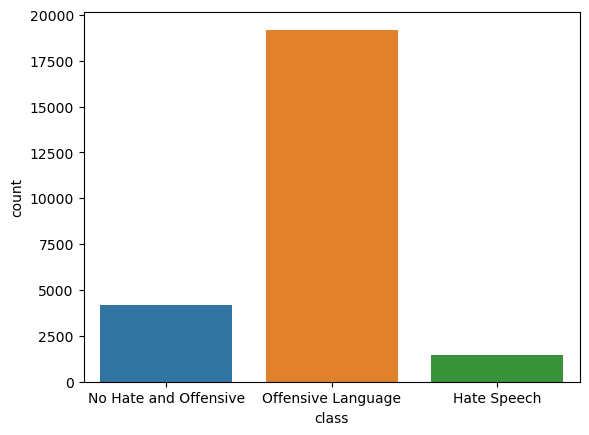

In [20]:
sns.countplot(x=df['class'], hue=df['class']);

&nbsp;&nbsp;&nbsp;Bu görsele bakınca SMOTE kütüphanesinin bize gerekeceğini anlayabiliyoruz, hedef sütununundaki değerlerin dengesizliğinden ama bunu en son adımda yapalım modellemeden önce. Bu yüzden şimdi 'tweet' sütunumuzda en sık geçen kelimelerin görsel bir özetini gösterelim.

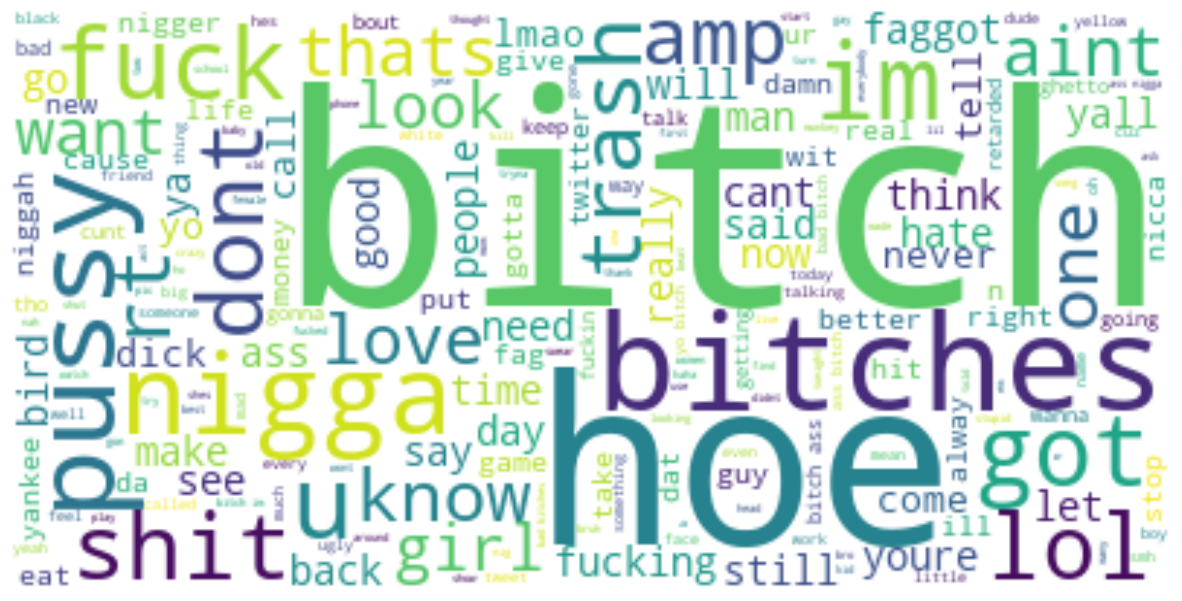

In [21]:
tweet = " ".join(i for i in df.tweet)
stopwords = set(STOPWORDS)
worldcloud = WordCloud(stopwords = stopwords, background_color = "white").generate(tweet)

plt.figure(figsize = (15,10))
plt.imshow(worldcloud,interpolation = "bilinear")
plt.axis("off")
plt.show()

&nbsp;&nbsp;&nbsp;Bu noktada SMOTE yapmadan önce eğitim ve hedef sütununu belirlemek zorunda olduğumuzdan bunu yapıyoruz.

In [22]:
x=df.drop(['class'],axis=1)
y=df[['class']]

&nbsp;&nbsp;&nbsp;Son olarak 'class' sütunu için SMOTE veri setimiz bir hayli dengesiz olduğu için, ona sentetik data oluşturarak onu dengeleyeceğiz ki modelimiz datamızı daha iyi öğrensin.

In [24]:
texts = df['tweet'].fillna('').astype(str)
y = df['class'].values  # 1D array

# TF-IDF
vect = TfidfVectorizer(max_features=5000, min_df=5, ngram_range=(1,2))
X = vect.fit_transform(texts)  # scipy.sparse matrix

# train/test split (SMOTE SADECE train üzerinde uygulanmalı)
X_train_sparse, X_test_sparse, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print("Before SMOTE (train):", Counter(y_train))

# Densify (küçük/orta veri için). Dikkat: büyük veri RAM sorununa yol açabilir.
X_train = X_train_sparse.toarray()
X_test = X_test_sparse.toarray()

# SMOTE uygulama (yalnızca train)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE (train_resampled):", Counter(y_train_res))

# Sonuçları DataFrame'e koymak istersen (opsiyonel)
cols = [f"tfidf_{i}" for i in range(X_train_res.shape[1])]
df_resampled = pd.DataFrame(X_train_res, columns=cols)
df_resampled['class'] = y_train_res

Before SMOTE (train): Counter({'Offensive Language': 15352, 'No Hate and Offensive': 3330, 'Hate Speech': 1144})
After SMOTE (train_resampled): Counter({'Offensive Language': 15352, 'Hate Speech': 15352, 'No Hate and Offensive': 15352})


&nbsp;&nbsp;&nbsp;Bir de son halini görelim hedef sütunumuzun: 

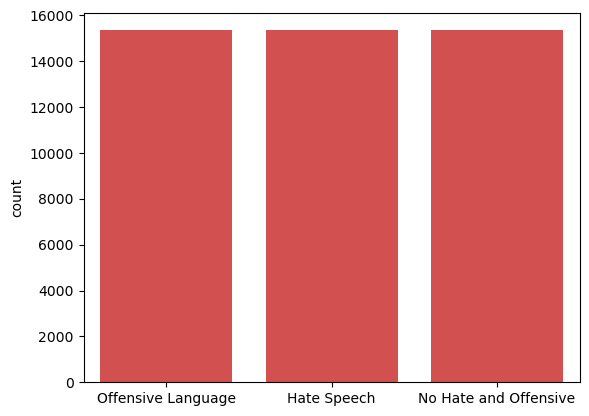

In [25]:
sns.countplot(x = y_train_res, color='#e93a3a');

## <font color="#e93a3a"> Model and Testing: </font>

&nbsp;&nbsp;&nbsp; Artık datasetimiz modellemeye hazır hale geldi. Biz genelde bu kısımda hedef sütunu ve eğitim datasını kodsal olarak belirtiriz, fakat ben projemde bu kısmı SMOTE kodları içerisinde yazmıştım. Bu sebeple modelimizi önce makine öğrenme modellerine direk tabii tutacağız. Bu projede sütunlarımız metinsel olduğundan bu gibi durumlarda biz genelde Pipeline kullanarak 'TfidfVectorizer' dan destek alırız. Fakat ben yine modelimin datasını x ve y olarak ayırırken eğitim datamı TfidfTransformer'dan geçirdim yani direk test edebilir hale getirdim halihazırda eğitmek için. O yüzden önce rastgele seçtiğimiz 'RandomForestClassifier' sınıflandırma yöntemi ile başlayalım.

In [26]:
clf = Pipeline([('Classifier', RandomForestClassifier(random_state=42))])

In [29]:
clf.fit(X_train_res, y_train_res)

Pipeline(steps=[('Classifier', RandomForestClassifier(random_state=42))])

In [30]:
tahmin=clf.predict(X_test)

In [31]:
accuracy_score(tahmin,y_test)

0.8795642525721202

In [32]:
confusion_matrix(tahmin,y_test)

array([[ 100,   16,  118],
       [  23,  707,  167],
       [ 163,  110, 3553]])

In [33]:
print(classification_report(tahmin,y_test))

                       precision    recall  f1-score   support

          Hate Speech       0.35      0.43      0.38       234
No Hate and Offensive       0.85      0.79      0.82       897
   Offensive Language       0.93      0.93      0.93      3826

             accuracy                           0.88      4957
            macro avg       0.71      0.71      0.71      4957
         weighted avg       0.88      0.88      0.88      4957



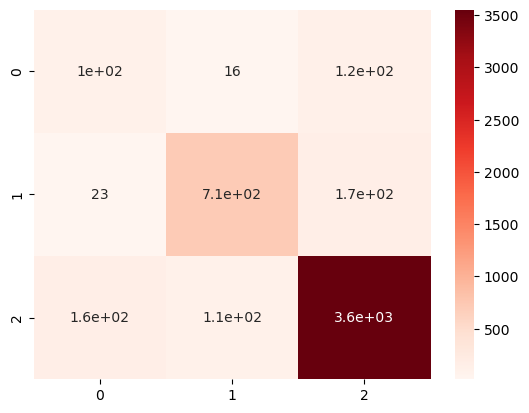

In [34]:
sns.heatmap(confusion_matrix(tahmin,y_test), annot=True, cmap='Reds');

&nbsp;&nbsp;&nbsp;'RandomForestClassifier' yöntemi sonuçlarına bakılırsa accuracy_score'umuz 0.8795 gibi bir değer geliyor. Bu demektir ki modelimiz bu yöntem ile eğitildiğinde tahmin doğruluk oranı yaklaşık %87 doğru tahmin getiriyor. Peki ya bizim veri setimiz için en uygun model nedir, sorusuna, kalan diğer modelleri de deneyen kodumuzu yazarak cevap arayalım.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# modeller (estimator nesneleri) -- pipeline içinde her biri bir son adım olacak
b = BernoulliNB()
l = LogisticRegression(max_iter=1000)
d = DecisionTreeClassifier()
r = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
kn = KNeighborsClassifier()
ab = AdaBoostClassifier(random_state=42)
mn = MultinomialNB()

def algo_test(X, y):
    """
    x: pandas Series (metin sütunu) veya 1-D array-like
    y: 1-D array-like (etiketler) -- tercihen sayısal veya label encode edilmiş
    """
    modeller = [b, l, d, r, gb, kn, ab, mn]
    isimler = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier",
               "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
               "AdaBoostClassifier", "MultinomialNB"]

    # Eğer y DataFrame şeklindeyse Series'e indirgeme
    if hasattr(y, "shape") and (len(y.shape) == 2 and y.shape[1] == 1):
        y = y.ravel()
        

    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl = []

    print("Veriler hazır, modeller deneniyor...")
    for model in modeller:
        print(f"{model.__class__.__name__} modeli eğitiliyor!..")

        # Her model için pipeline (TfidfVectorizer -> classifier)
        pipe = Pipeline([
            ("clf", model)
        ])

        # fit
        pipe.fit(X_train_res, y_train_res)

        # predict
        preds = pipe.predict(X_test)

        # metrikleri hesapla
        accuracy.append(accuracy_score(y_test, preds))
        precision.append(precision_score(y_test, preds, average="micro"))
        recall.append(recall_score(y_test, preds, average="micro"))
        f1.append(f1_score(y_test, preds, average="micro"))
        mdl.append(pipe)  # pipeline'ı sakla

        print(confusion_matrix(y_test, preds))

    print("Eğitim tamamlandı.")

    metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"] = mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    best_model = metrics.iloc[0]["Model"]

    # En iyi model ile test seti üzerinde detaylı rapor
    best_preds = best_model.predict(X_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, best_preds))
    print("Classification Report:")
    print(classification_report(y_test, best_preds))

    print("Diğer Modeller:")
    # metrics'ten model sütununu çıkarıp döndür
    return metrics.drop("Model", axis=1)

In [36]:
algo_test(X, y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor!..
[[ 126   41  119]
 [  31  743   59]
 [ 280  195 3363]]
LogisticRegression modeli eğitiliyor!..
[[ 153   21  112]
 [  46  732   55]
 [ 283  166 3389]]
DecisionTreeClassifier modeli eğitiliyor!..
[[ 108   18  160]
 [  54  668  111]
 [ 247  162 3429]]
RandomForestClassifier modeli eğitiliyor!..
[[ 100   23  163]
 [  16  707  110]
 [ 118  167 3553]]
GradientBoostingClassifier modeli eğitiliyor!..
[[ 153   51   82]
 [  22  800   11]
 [ 320  334 3184]]
KNeighborsClassifier modeli eğitiliyor!..
[[ 170  102   14]
 [ 126  698    9]
 [1408 1959  471]]
AdaBoostClassifier modeli eğitiliyor!..
[[  54  162   70]
 [   0  828    5]
 [ 102  936 2800]]
MultinomialNB modeli eğitiliyor!..
[[ 148   35  103]
 [  58  715   60]
 [ 395  229 3214]]
Eğitim tamamlandı.
En başarılı model:  RandomForestClassifier
Confusion Matrix:
[[ 100   23  163]
 [  16  707  110]
 [ 118  167 3553]]
Classification Report:
                       precision    rec

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.879564,0.879564,0.879564,0.879564
LogisticRegression,0.862215,0.862215,0.862215,0.862215
BernoulliNB,0.853742,0.853742,0.853742,0.853742
DecisionTreeClassifier,0.848295,0.848295,0.848295,0.848295
GradientBoostingClassifier,0.834577,0.834577,0.834577,0.834577
MultinomialNB,0.822473,0.822473,0.822473,0.822473
AdaBoostClassifier,0.742788,0.742788,0.742788,0.742788
KNeighborsClassifier,0.270123,0.270123,0.270123,0.270123


&nbsp;&nbsp;&nbsp; Algo testine göre veri setimize en uygun model yani doğruluk oranı en yüksek olan geleneksel makine öğrenme modeli 'RandomForestClassifier' çıkıyor. Sonuçlarını zaten yukarıda görmüştük, fakat bir başka yöntem daha var doğruluk oranını yükseltebileceğimizi umduğumuz ve şimdi o yöntemi yani SVM (Support Vector Machine) yöntemi de yakından inceleyeceğiz ve 'RandomForestClassifier' modelinden daha iyi sonuç verip vermediğine bakacağız.

In [37]:
svm=Pipeline([('Classifier', SVC(random_state=42))])

In [38]:
svm.fit(X_train_res,y_train_res)

Pipeline(steps=[('Classifier', SVC(random_state=42))])

In [39]:
tahmin2=svm.predict(X_test)

In [40]:
accuracy_score(tahmin2,y_test)

0.8890457938269114

In [41]:
confusion_matrix(tahmin2,y_test)

array([[  36,    3,   39],
       [  18,  665,   93],
       [ 232,  165, 3706]])

In [42]:
print(classification_report(tahmin2,y_test))

                       precision    recall  f1-score   support

          Hate Speech       0.13      0.46      0.20        78
No Hate and Offensive       0.80      0.86      0.83       776
   Offensive Language       0.97      0.90      0.93      4103

             accuracy                           0.89      4957
            macro avg       0.63      0.74      0.65      4957
         weighted avg       0.93      0.89      0.91      4957



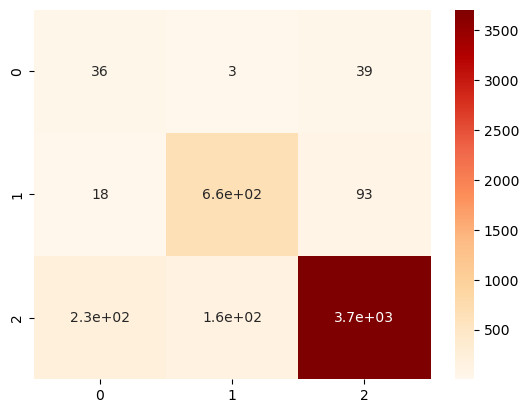

In [43]:
sns.heatmap(confusion_matrix(tahmin2,y_test), annot=True, cmap='OrRd');

In [77]:
joblib.dump(svm,'svm_hate.pkl') # Dosyayı kaydettik

['svm_hate.pkl']

&nbsp;&nbsp;&nbsp; Yukarıda da görüldüğü üzere 'Support Vector Classifier' öğrenme modeli kısaca SVC bizim veri setimiz için bir önceki 'RandomForestClassifier' modelinden daha iyi doğru tahmin veriyor. Çünkü SVC modelinin doğruluk oranı yani accuracy_score'u 0.8890 yani %89 gibi bir değerde ve daha yüksek oranda. Sonucumuzu da yine yeni heatmap'te göstermiş de olduk ve modelimizi kaydettik. <br>

&nbsp;&nbsp;&nbsp;Veri setimizi yukarıda olduğu gibi geleneksel makine öğrenme modellerinde eğitip inceledik. Peki ya **Derin Öğrenme** ile eğitmek istersek ne yapacağız nasıl sonuçlar alırız diğer bölümde buna bakıyor olacağız.

### <font color="#e93a3a"> Derin Öğrenme: </font>

&nbsp;&nbsp;&nbsp; Tüm bu modellemeyi **Derin Öğrenme** ile yapmak isteseydik doğruluk oranımız nasıl sonuçlanırdı bu bölümde buna bakıyor olacağız. Veri setimizi derin öğrenmeye sokabimek adına hedef sütunumuzu Encoder'dan geçirmemiz ve datamızı vektörize ettikten sonda diziye çevirmemiz gereklidir. Tüm bunlardan sonra da veri setimiz derin öğrenme yöntemi ile eğitime hazır oluyor, haydi kodlayalım.

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# varsayım: df değişkeninde 'tweet' ve 'class' sütunları var
texts = df['tweet'].fillna('').astype(str).values
y = df['class'].values

# Label encoding (zaten yapmışsın)
le = LabelEncoder()
y_enc = le.fit_transform(y)  # örn: Hate_Speech=0, Offensive_Language=1, No_Hate_and_Offensive=2

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    texts, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# TF-IDF vektörleştirici
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf  = tfidf.transform(x_test)

# Dense (küçük/orta veri için). Eğer çok büyükse TruncatedSVD ile boyut indirgeme tercih et.
x_train_dense = x_train_tfidf.toarray()
x_test_dense  = x_test_tfidf.toarray()

# Model (çıktı katmanı: 3 nöron + softmax)
num_classes = len(np.unique(y_enc))  # 3
model = Sequential()
model.add(Dense(150, activation='relu', input_shape=(x_train_dense.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(220, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(160, activation='relu'))
model.add(Dense(125, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(75, activation='relu'))
model.add(Dense(54, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(5, activation='relu'))

# Çıktı katmanı: sınıf sayısı kadar nöron ve softmax
model.add(Dense(num_classes, activation='softmax'))

# Derleme: integer etiketler için sparse_categorical_crossentropy kullan
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    x_train_dense, y_train,
    validation_data=(x_test_dense, y_test),
    batch_size=32,
    shuffle=True,
    verbose=1,
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8300 - loss: 0.4612 - val_accuracy: 0.8788 - val_loss: 0.3445
Epoch 2/100
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8914 - loss: 0.3041 - val_accuracy: 0.8838 - val_loss: 0.3220
Epoch 3/100
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9093 - loss: 0.2429 - val_accuracy: 0.8868 - val_loss: 0.3393
Epoch 4/100
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9254 - loss: 0.1983 - val_accuracy: 0.8828 - val_loss: 0.3383
Epoch 5/100
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9390 - loss: 0.1601 - val_accuracy: 0.8709 - val_loss: 0.4072
Epoch 6/100
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9538 - loss: 0.1234 - val_accuracy: 0.8747 - val_loss: 0.4378
Epoch 7/100
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9631 - loss: 0.0963 - val_accuracy: 0.8790 - val_loss: 0.6657
Epoch 8/100
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9720 - loss: 0.0761 - val_accu

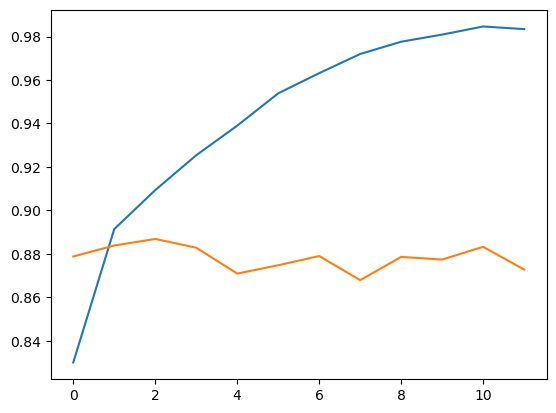

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy']);

&nbsp;&nbsp;&nbsp;Yeni modelimizin **Derin Öğrenme** yöntemi ile alınan sonuçlarına da bakılırsa; bizim veri setimizi Derin Öğrenme Geleneksel Makine Öğrenmelerinden daha hızlı kavrıyor, işliyor ve daha iyi tahminlerde bulunabiliyor diyebiliriz. Yani Derin Öğrenme ile eğittiğimiz modelimiz bir cümle içerisindeki nefret ya da agresyonu olup olmadığını diğer yöntemlerin hepsinden daha doğru tahmin edebiliyor matematiksel sonuçlarıma göre. Son yöntemimiz ile eğittiğimiz modelin doğruluk oranının geçmişine de yakından bakalım.

In [47]:
history.history['accuracy']

[0.8299707174301147,
 0.8913547992706299,
 0.9093109965324402,
 0.925350546836853,
 0.9389690160751343,
 0.9538484811782837,
 0.9631292223930359,
 0.9719560146331787,
 0.9776051640510559,
 0.9808837175369263,
 0.9846161603927612,
 0.9834056496620178]

&nbsp;&nbsp;&nbsp;Keras Derin Öğrenme Modelinin doğruluk oranı geçmişine baktığımızda, bu modelde tahminlerimizin doğruluk oranı bir ara 0.9834'leri görüyor son epoch'larda. Bu doğruluk oranımızın %98 üzerinde olduğunu ve modelimizin verilen datayı iyi öğrendiğini gösterir.

In [85]:
model.save('hate_detection_model.h5')

**Modelleme Genel Sonuçları:** &nbsp;&nbsp;Sonuçta bu projemizde alınan tweet'lerde o cümleler içerisinde insanların kullandğı agresig ya da nefret söylemi veya nötr kelimelerin olup olmadığını saptayabilen modeller oluşturduk ve bu modeller için önce geleneksel makine öğrenme yöntemlerini daha sonrasında da Derin Öğrenme yöntemini kullanarak modellerimizi eğitip test ettik. Alınan sonuçlara göre; data setimiz geleneksel makine öğrenmeleri içinde en çok 'SVM' yani Support Vector Machine sınıflandırma yöntemi ile uyumlu çıktı ve bu yöntemi kullanarak oluşturduğumuz modelin doğruluk oranı yani accuracy_score %89 oranla doğru tahmin edebilmiştir. <br>
&nbsp;&nbsp;&nbsp; Daha sonrasında veri setimizi Derin Öğrenme yöntemi ile eğittiğimizde ise yeni oluşan modelin tahminlerinin doğruluk oranı %98'leri görmüştür ve tüm sonuçlar görselleştirilmiştir. Bu durumda Derin Öğrenme yöntemi normal makine öğrenme yöntemini masada yenmiştir bu veri için<br>

### <font color="#e93a3a"> WordCloud ile Görselleştirme: </font>

&nbsp;&nbsp;&nbsp; Bu kısımda hedef sütunumuzda  0 - 'Nefret Söylemi', 1 - 'Hakaret içeren dil' ve 2 - 'Nefret ve hakaret içermeyen içerik' i tutuyordu. Şimdi bu sütunumuzun en çok geçen kelimelerini WordCloud kütüphanesinden destek alarak görselleştiriyor olacağız. Önce 'class' sınıfını tekrar label 2-1-0 haline getirelim.

In [60]:
df["class"] = df["class"].map({"Hate Speech":0, "Offensive Language":1, "No Hate and Offensive":2})

In [61]:
def wc(data,color):
    plt.figure(figsize=(10,10))
    wc=WordCloud(background_color=color,stopwords=STOPWORDS)
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis('off')

&nbsp;&nbsp;&nbsp;Şimdi 'class' sütunumuzda 0 - 'Nefret Söylemi', 1 - 'Hakaret içeren dil' ve 2 - 'Nefret ve hakaret içermeyen içerik' i tutuyordu. Şimdi bu sütunumuzu WordCloud ile görselleştirelim.

In [62]:
Hate_Speech=df[df['class']==0]
Offensive_Language=df[df['class']==1]
No_Hate_and_Offensive=df[df['class']==2]

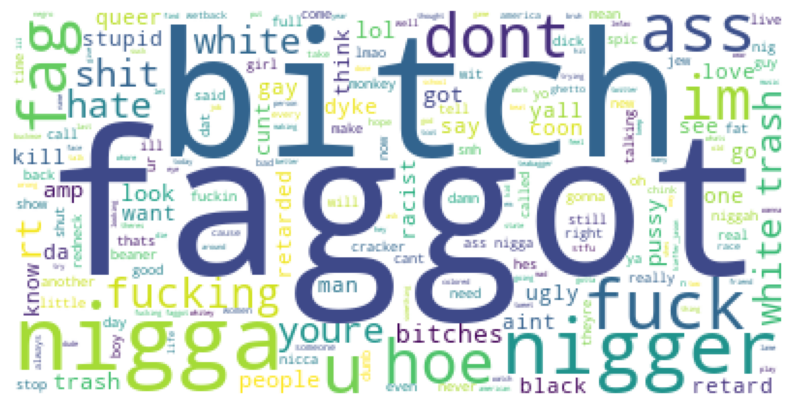

In [63]:
wc(Hate_Speech['tweet'],'white')

In [64]:
def wc2(data):
    plt.figure(figsize=(10,10))
    mask=np.array(Image.open('cloud.png'))
    wc=WordCloud(stopwords=STOPWORDS, mask=mask)
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis('off')

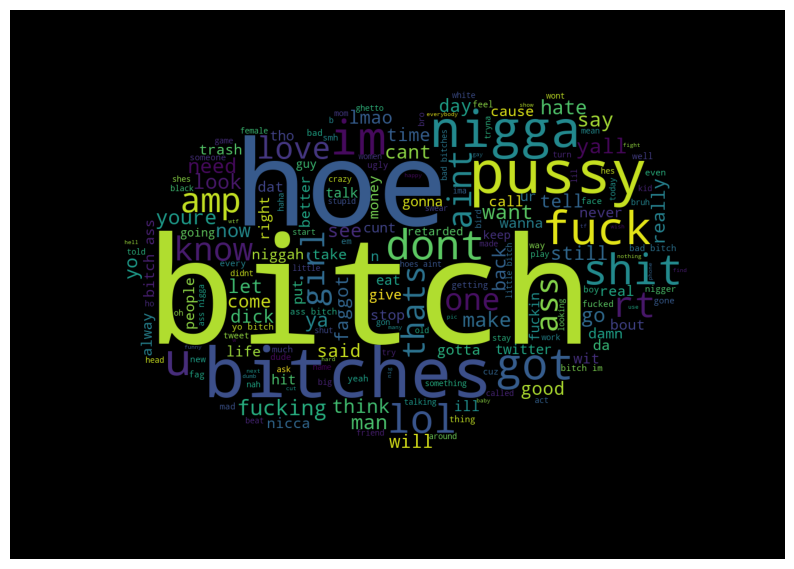

In [65]:
wc2(Offensive_Language['tweet']) 

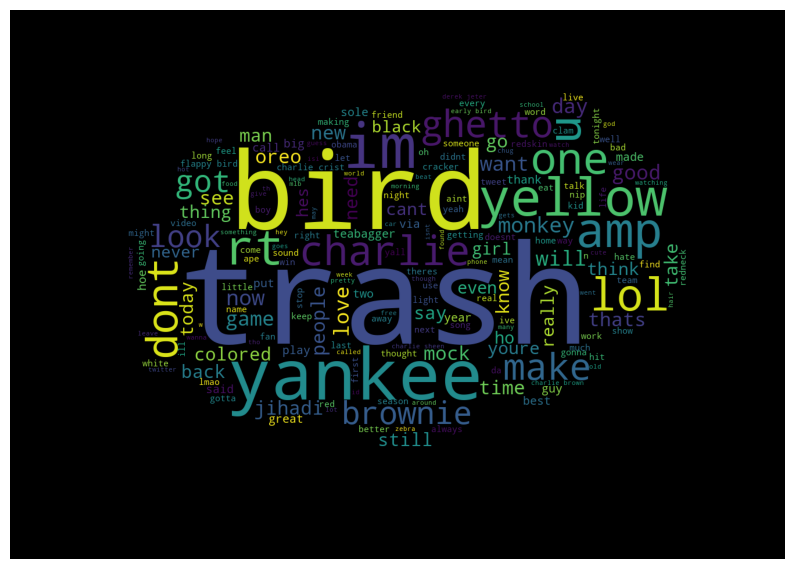

In [66]:
wc2(No_Hate_and_Offensive['tweet'])

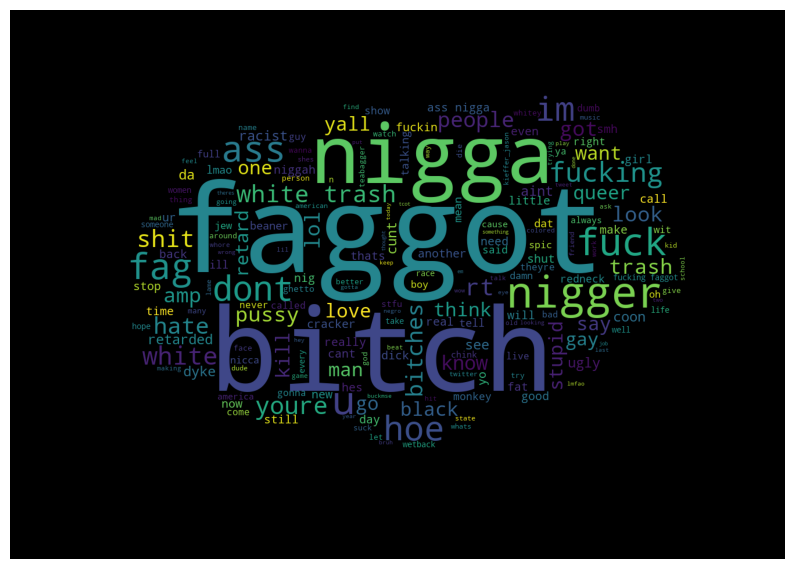

In [67]:
wc2(Hate_Speech['tweet'])

**Conclusion:** &nbsp;&nbsp; Bu projemizde elimizde text halinde bulunan tweet'ler olan veri setimiz ile bir model geliştirmiş olduk. Bu model bir cümlenin agresyon ya da nefret söylemi içerip içermediğini tahmin edebiliyor ve bu modeli geleneksel makine öğrenme modellerinden sınıflandırma modeli olan 'SVM' ile eğittik. Modelimizin doğruluk oranı yani accuracy_score'u %89 gibi bir sonuç verirken bu modelimizin verilen cümle üzerinde nefret söylemi, agresyon ya da nötr olup olmadığına dair yapacağı tahminlerin %89'nün doğru olacağı sonucu verir bizlere. <br> 
&nbsp;&nbsp;&nbsp;Diğer yandan aynı datayı **derin öğrenme** ile eğittiğimizde yeni modelimizin tahmin oranlarının %98 doğruluk oranlarını gördüğünü el de ettik ve görselleştirdik. 
&nbsp;&nbsp;&nbsp; 2026 ve sonrası yıllarda sosyal platformlar bu denli değer kazanmış ve insanlar bir durum, ülke ya da insan hakkındaki düşüncelerini Twitter yani şyuan X gibi platformlarda beyan ederken, bu cümlelerin hakaret veyahut nefret söylemleri içeripp içermediğini toplumun nereye gittiğini bunun suç olup olmadığını bizler düşünürken bunları sadece yazılan birkaç tweet üzerinden dahi cümle analizi ile tahmin edebilen buna benzer modellerin yakın gelecekte çok fazla değer görüleceği aşikardır.

Ve kapanış..